# 📉 Project 1: Value at Risk (VaR) Calculator

**Author:** Eugenio Mandalà  
**Date:** March 2026

## Objective
Measure and compare the **daily risk** of four assets: Apple, Nvidia, US Bonds and Bitcoin.  
Two methods are used and compared:
- **Historical VaR** → based on real past data
- **Parametric VaR** → based on mean and standard deviation

## Key Question
*How much can I lose in a single day, in the worst 5% of cases?*

In [11]:
# Import libraries
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Define assets to analyze
assets = {
    "Apple (AAPL)":   "AAPL",
    "Nvidia (NVDA)":  "NVDA",
    "US Bonds (TLT)": "TLT",
    "Bitcoin (BTC)":  "BTC-USD"
}

In [13]:
# Download historical price data (2020-2024) and calculate daily returns
import warnings
warnings.filterwarnings('ignore')

results = {}

for name, ticker in assets.items():
    data = yf.download(ticker, start="2020-01-01", end="2024-01-01", 
                       auto_adjust=True, progress=False)
    returns = data['Close'].pct_change().dropna()

    var_hist  = float(np.percentile(returns, 5))
    mean      = float(returns.mean().iloc[0])
    std       = float(returns.std().iloc[0])
    var_param = mean - 1.645 * std

    results[name] = {
        "returns":   returns,
        "var_hist":  var_hist,
        "var_param": var_param,
        "std":       std
    }

print("✅ Data downloaded successfully for all assets.")

✅ Data downloaded successfully for all assets.


## Figure 1 — Daily Return Distributions
Each histogram shows the distribution of daily returns.  
The red and black dashed lines mark the **Historical** and **Parametric VaR** thresholds.

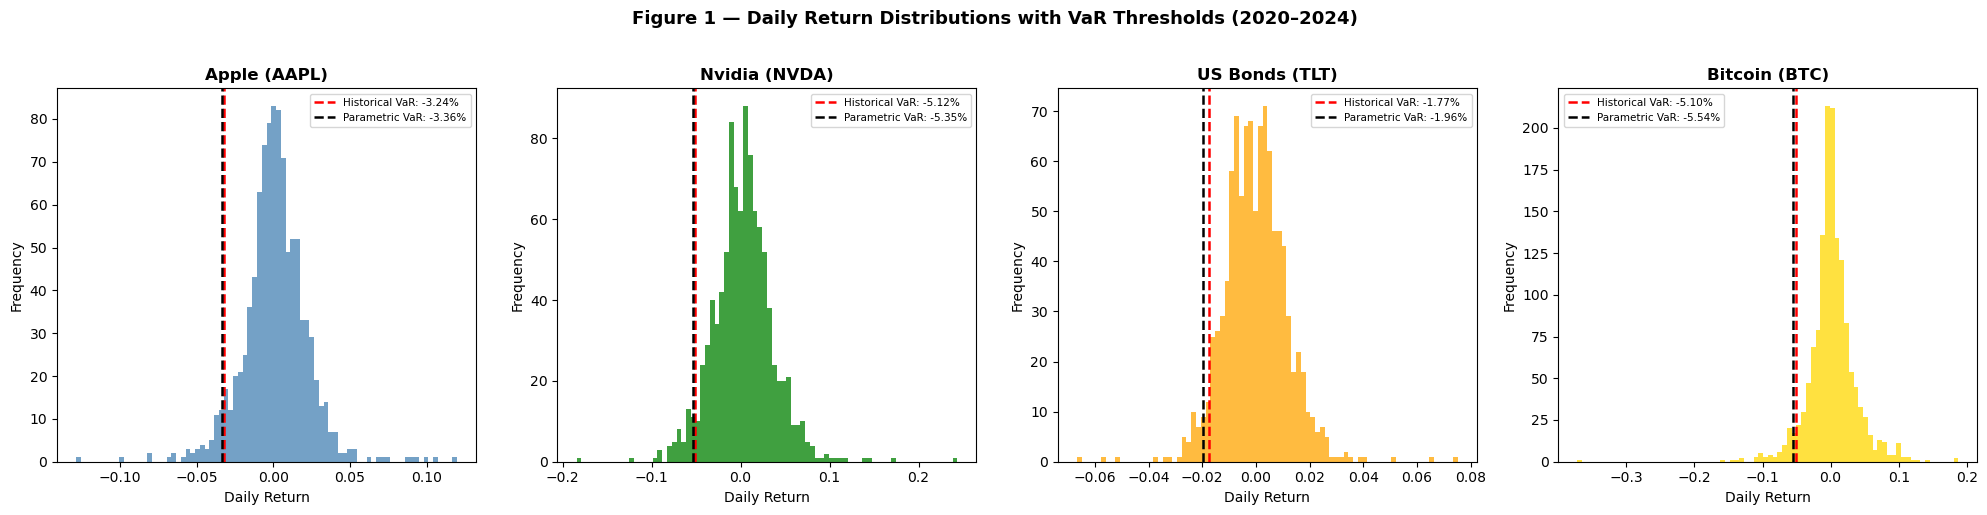

In [16]:
# Plot return distributions for all four assets
colors = ['steelblue', 'green', 'orange', 'gold']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.hist(res["returns"], bins=80, color=color, alpha=0.75)
    ax.axvline(res["var_hist"],  color='red',   linestyle='--', linewidth=1.8,
               label=f'Historical VaR: {res["var_hist"]:.2%}')
    ax.axvline(res["var_param"], color='black', linestyle='--', linewidth=1.8,
               label=f'Parametric VaR: {res["var_param"]:.2%}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7.5)

plt.suptitle('Figure 1 — Daily Return Distributions with VaR Thresholds (2020–2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Figure 2 — Risk Comparison
Bar chart comparing Historical vs Parametric VaR across all assets.  
The higher the bar, the **riskier** the asset.

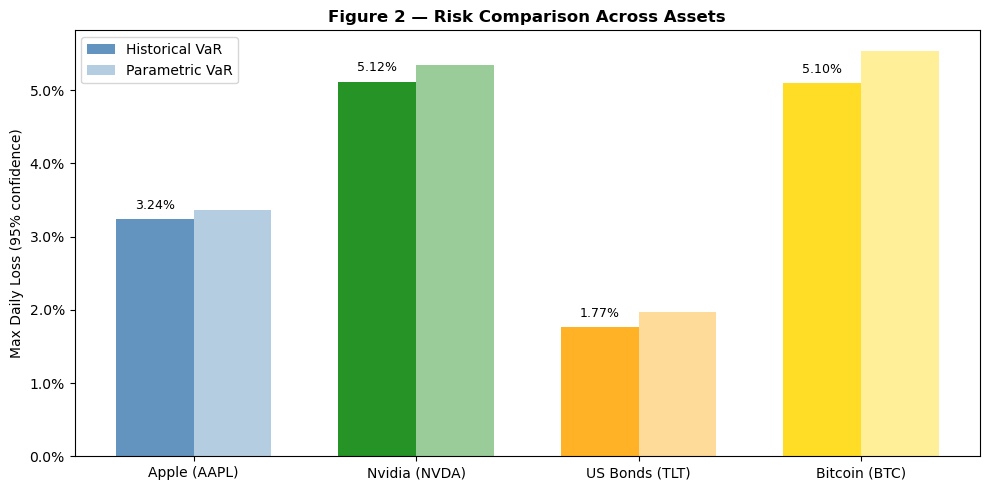

In [17]:
# Bar chart comparing VaR across assets
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results.keys())
var_h  = [abs(results[n]["var_hist"])  for n in names]
var_p  = [abs(results[n]["var_param"]) for n in names]

x      = np.arange(len(names))
width  = 0.35
colors_bar = ['steelblue', 'green', 'orange', 'gold']

bars1 = ax.bar(x - width/2, var_h, width, label='Historical VaR',
               color=colors_bar, alpha=0.85)
ax.bar(x + width/2, var_p, width, label='Parametric VaR',
       color=colors_bar, alpha=0.4)

ax.set_ylabel('Max Daily Loss (95% confidence)')
ax.set_title('Figure 2 — Risk Comparison Across Assets', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Summary Table & Key Findings

In [18]:
# Print summary table
print("=" * 72)
print("  SUMMARY TABLE")
print("=" * 72)
print(f"\n  {'Asset':<20} {'Hist. VaR':>12} {'Param. VaR':>13} {'Daily Vol.':>12} {'Difference':>12}")
print("  " + "-" * 68)
for name, res in results.items():
    diff = abs(res['var_hist'] - res['var_param'])
    print(f"  {name:<20} {res['var_hist']:>12.2%} {res['var_param']:>13.2%} {res['std']:>12.2%} {diff:>12.2%}")

  SUMMARY TABLE

  Asset                   Hist. VaR    Param. VaR   Daily Vol.   Difference
  --------------------------------------------------------------------
  Apple (AAPL)               -3.24%        -3.36%        2.11%        0.12%
  Nvidia (NVDA)              -5.12%        -5.35%        3.42%        0.23%
  US Bonds (TLT)             -1.77%        -1.96%        1.18%        0.20%
  Bitcoin (BTC)              -5.10%        -5.54%        3.48%        0.44%


## Conclusions

1. **Nvidia** is the riskiest equity — Historical VaR of -5.12%, nearly double that of US Bonds.
2. **US Bonds** are the safest asset — confirming their role as a defensive instrument in any portfolio.
3. **Bitcoin** shows the largest gap between Historical and Parametric VaR (0.44%) — evidence of extreme tail events like the 2021-2022 crashes that the parametric model fails to capture.
4. For assets with **fat tails** (like BTC), Historical VaR is always the more reliable measure.